# Counterfactual Explanations with **DiCE**
### A hands-on lab on the UCI Adult Income dataset

---

A machine-learning model has just told someone *"no"*. The natural next question is
not **"why?"** but:

> ### "What would I have to change for the answer to be **yes**?"

That question is what a **counterfactual explanation** answers, and
[**DiCE**](https://github.com/interpretml/DiCE) (Diverse Counterfactual Explanations,
Mothilal, Sharma & Tan, FAT* 2020) is the library that generates them.

**By the end of this lab you will be able to:**

| # | Skill |
|---|-------|
| 1 | Explain what a counterfactual explanation is, and how it differs from feature attribution |
| 2 | Wire a scikit-learn pipeline into DiCE (`Data`, `Model`, `Dice`) |
| 3 | Generate counterfactuals and *read* them critically |
| 4 | Constrain them to **actionable** features and realistic ranges |
| 5 | Compare the `random`, `genetic` and `kdtree` search methods |
| 6 | Measure counterfactual quality: **validity, sparsity, proximity, diversity** |
| 7 | Turn counterfactuals into local and global feature importance |

**Prerequisites:** basic pandas, scikit-learn, and matplotlib.
**Runtime:** roughly 5–10 minutes end to end.

---

## 1. The idea in one picture

Imagine the model's world as a map. Every person is a dot. A curve — the **decision
boundary** — splits the map into "the model says yes" and "the model says no".

A counterfactual is simply **the shortest walk from your dot to the other side of the
curve**, described in the language of the features.

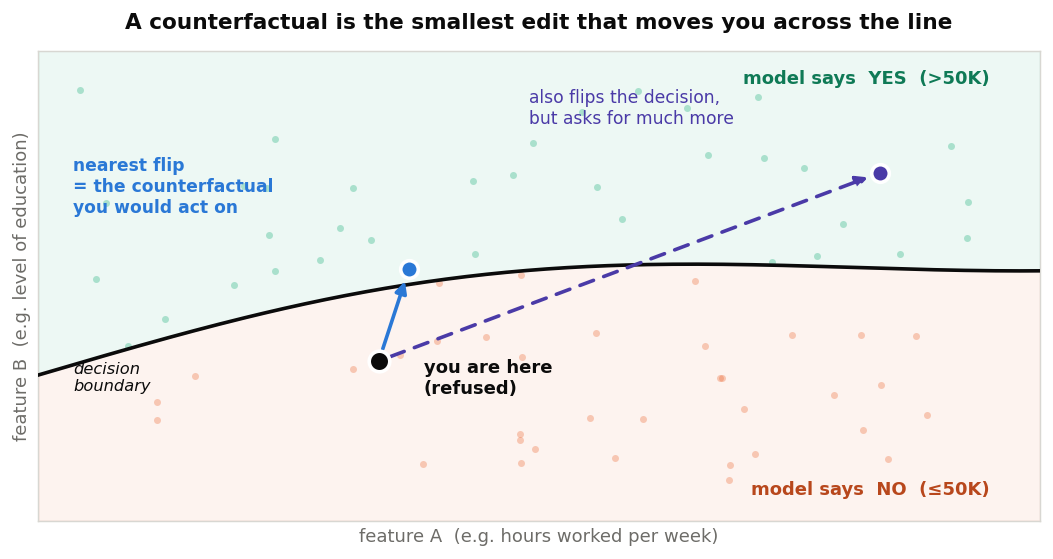

Two things to notice, because students miss them every time:

1. **Many points sit across the boundary.** So there is never *one* counterfactual —
   there is a *set* of them. That is the "Diverse" in DiCE.
2. **A counterfactual explains the *model*, not the world.** It tells you what the
   model would have done, not what would really happen if you went back to college.
   Keep that distinction sharp.

## 2. Counterfactual ≠ feature attribution

Both are "explanations", but they answer different questions. Do not let students
mix them up.

| | **Attribution** (SHAP, LIME, permutation importance) | **Counterfactual** (DiCE) |
|---|---|---|
| Question answered | *Why this prediction?* | *What would change it?* |
| Output | a number per feature | one or more **complete alternative records** |
| Points | backwards, at the decision just made | forwards, at a decision you could get |
| Useful to | a modeller debugging the model | the **person affected** by the decision |
| Legal angle | describes the logic | supports a "right to explanation" style **recourse** |

A useful slogan:

> **Attribution is a post-mortem. A counterfactual is a to-do list.**

They are complementary — a good report shows both.

## 3. Setup

`dice-ml` is on PyPI. The cell below installs it only if it is missing, so the
notebook is safe to re-run.

In [1]:
import subprocess
import sys

try:
    import dice_ml
except ImportError:
    print("installing dice-ml ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dice-ml"])
    import dice_ml



installing dice-ml ...


In [2]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# One small colour-blind-safe palette, reused by every chart below.
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948",
     "grid": "#d8d7d2", "ink": "#0b0b0b", "muted": "#6d6c68"}

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["grid"], "axes.labelcolor": C["muted"],
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "grid.color": C["grid"], "grid.linewidth": 0.8,
    "font.size": 10, "legend.frameon": False,
})
print("Ready.")

Ready.


## 4. The data: UCI Adult Income

The **Adult** dataset (Kohavi, 1996) holds ~48,000 records from the 1994 US census.
The task: predict whether a person earns **more than \$50,000 a year**.

DiCE ships a cleaned version of it, with the messy 40-odd occupation codes already
folded into a handful of readable groups — perfect for a teaching notebook, because
a counterfactual that says *"become a `Prof-specialty`"* is much less legible than
one that says *"move into a `Professional` role"*.

In [3]:
from dice_ml.utils import helpers

data = helpers.load_adult_income_dataset()

print("rows, columns:", data.shape)
data.head()

rows, columns: (26048, 9)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,28,Private,Bachelors,Single,White-Collar,White,Female,60,0
1,30,Self-Employed,Assoc,Married,Professional,White,Male,65,1
2,32,Private,Some-college,Married,White-Collar,White,Male,50,0
3,20,Private,Some-college,Single,Service,White,Female,35,0
4,41,Self-Employed,Some-college,Married,White-Collar,White,Male,50,0


In [4]:
outcome = "income"                                   # 1 = earns >50K, 0 = does not
continuous_features = ["age", "hours_per_week"]      # everything else is categorical
categorical_features = [c for c in data.columns
                        if c not in continuous_features + [outcome]]

schema = pd.DataFrame({
    "feature": continuous_features + categorical_features,
    "type": ["continuous"] * len(continuous_features)
            + ["categorical"] * len(categorical_features),
    "values / range": (
        [f"{data[c].min()} - {data[c].max()}" for c in continuous_features]
        + [", ".join(map(str, sorted(data[c].unique()))) for c in categorical_features]),
})

print("Share of people earning >50K: %.1f%%\n" % (100 * data[outcome].mean()))
schema

Share of people earning >50K: 23.9%



,feature,type,values / range
0,age,continuous,17 - 90
1,hours_per_week,continuous,1 - 99
2,workclass,categorical,"Government, Other/Unknown, Private, Self-Employed"
3,education,categorical,"Assoc, Bachelors, Doctorate, HS-grad, Masters,..."
4,marital_status,categorical,"Divorced, Married, Separated, Single, Widowed"
5,occupation,categorical,"Blue-Collar, Other/Unknown, Professional, Sale..."
6,race,categorical,"Other, White"
7,gender,categorical,"Female, Male"


> **Note the class imbalance.** Only about a quarter of the people earn >\$50K.
> That is exactly why counterfactuals are interesting here: for most applicants the
> model says *no*, and *"what would flip it?"* is a real question.

### A quick look before we model

Two features do a lot of the work. Look at them first, so the counterfactuals later
are not a surprise.

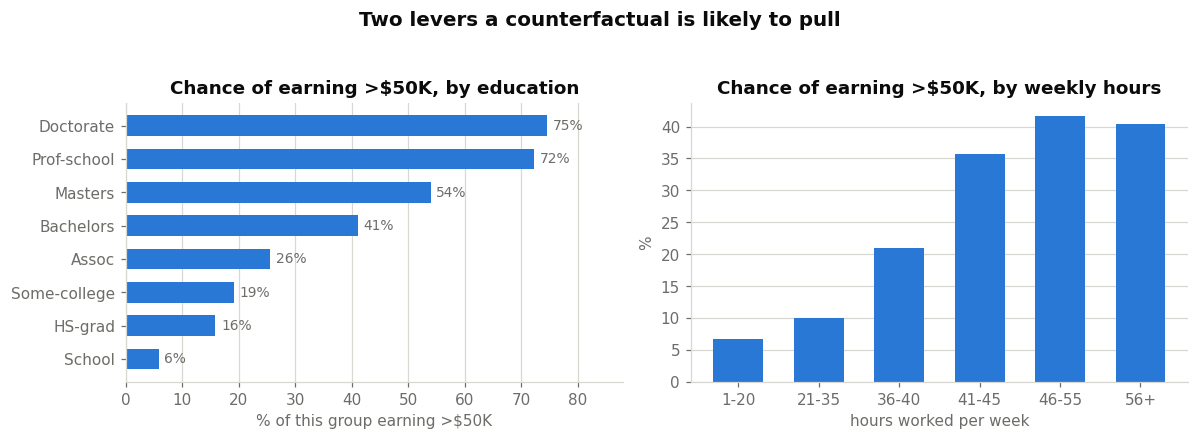

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

edu = data.groupby("education")[outcome].mean().sort_values()
axes[0].barh(edu.index, edu.values * 100, color=C["blue"], height=0.62)
axes[0].set_title("Chance of earning >\$50K, by education")
axes[0].set_xlabel("% of this group earning >\$50K")
axes[0].set_xlim(0, max(edu.values * 100) * 1.18)
axes[0].xaxis.grid(True)
axes[0].set_axisbelow(True)
for y, v in enumerate(edu.values * 100):
    axes[0].text(v + 1, y, f"{v:.0f}%", va="center", color=C["muted"], fontsize=9)

bins, labels = [0, 20, 35, 40, 45, 55, 100], ["1-20", "21-35", "36-40",
                                              "41-45", "46-55", "56+"]
hrs = data.groupby(pd.cut(data["hours_per_week"], bins=bins,
                          labels=labels), observed=False)[outcome].mean()
axes[1].bar(hrs.index.astype(str), hrs.values * 100, color=C["blue"], width=0.62)
axes[1].set_title("Chance of earning >\$50K, by weekly hours")
axes[1].set_xlabel("hours worked per week")
axes[1].set_ylabel("%")
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

fig.suptitle("Two levers a counterfactual is likely to pull", y=1.04,
             fontsize=13, fontweight="bold", color=C["ink"])
plt.tight_layout()
plt.show()

## 5. Train the model we are going to explain

Two rules that trip people up when they first use DiCE:

1. **The model must accept the data in its original, human-readable form.** DiCE
   hands the model rows that look exactly like `data.head()` — with the string
   `"Bachelors"`, not a one-hot vector. So all encoding must live *inside* a
   scikit-learn `Pipeline`.
2. **Fit on the raw feature frame, not on an encoded matrix.** If you one-hot encode
   by hand first, DiCE will happily produce counterfactuals in one-hot space and
   they will be unreadable (and often invalid, e.g. two `education` values at once).

In [6]:
X = data.drop(columns=[outcome])
y = data[outcome]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

preprocess = ColumnTransformer(transformers=[
    ("num", StandardScaler(), continuous_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(n_estimators=200, max_depth=12,
                                          min_samples_leaf=5, random_state=0)),
])
model.fit(x_train, y_train)

print("accuracy : %.3f" % accuracy_score(y_test, model.predict(x_test)))
print("roc auc  : %.3f" % roc_auc_score(y_test, model.predict_proba(x_test)[:, 1]))

accuracy : 0.842
roc auc  : 0.892


## 6. DiCE's three objects

DiCE always needs the same three things. Learn this trio and the rest of the library
is easy.

| Object | What it wraps | Why DiCE needs it |
|---|---|---|
| `dice_ml.Data` | the **training dataframe** + which columns are continuous + the outcome column | to know each feature's legal range / categories, and to compute feature-scaling (MAD) for the distance term |
| `dice_ml.Model` | your **fitted estimator** + a backend (`"sklearn"`, `"TF2"`, `"PYT"`) | to query predictions during the search |
| `dice_ml.Dice` | the two above + a **`method`** | the search engine that actually finds counterfactuals |

Three search methods ship with the sklearn backend:

| `method` | How it searches | Good for |
|---|---|---|
| `"random"` | samples random feature values, keeps the ones that flip the label | fast, works with any model, great default for teaching |
| `"genetic"` | evolutionary search on an explicit loss (proximity + sparsity + diversity) | best control over the trade-offs |
| `"kdtree"` | looks up the nearest **real training rows** of the desired class | guarantees the counterfactual is a plausible, real person |

`"gradient"` also exists, but only for differentiable (TF/PyTorch) models.

[![Chat-GPT-Image-Sep-9-2026-09-00-37-PM.png](https://i.postimg.cc/LsgtShVD/Chat-GPT-Image-Sep-9-2026-09-00-37-PM.png)](https://postimg.cc/CZYBHhXn)

In [7]:
# DiCE wants the outcome column back in the frame it is given
train_dataset = x_train.copy()
train_dataset[outcome] = y_train

d = dice_ml.Data(dataframe=train_dataset,
                 continuous_features=continuous_features,
                 outcome_name=outcome)

m = dice_ml.Model(model=model, backend="sklearn")

exp_random = dice_ml.Dice(d, m, method="random")
print("explainer ready:", exp_random)

explainer ready: <dice_ml.explainer_interfaces.dice_random.DiceRandom object at 0x00000143A462D270>


## 7. Pick a person the model turned down

We deliberately choose the rejected applicant whose predicted probability is
**closest to the 0.5 boundary**. That is the most instructive case: recourse should
be short and believable. (Try a hopeless case later — exercise 1.)

In [8]:
proba_test = model.predict_proba(x_test)[:, 1]
rejected = x_test[proba_test < 0.5]
rejected_proba = proba_test[proba_test < 0.5]

borderline = int(np.argmax(rejected_proba))        # closest to the boundary
query_instance = rejected.iloc[[borderline]]

print("P(income > 50K) = %.3f  ->  predicted class 0 (rejected)\n"
      % rejected_proba[borderline])
query_instance

P(income > 50K) = 0.500  ->  predicted class 0 (rejected)



,age,workclass,education,marital_status,occupation,race,gender,hours_per_week
278,47,Self-Employed,Bachelors,Married,Professional,White,Male,30


## 8. Generate the first counterfactuals

Three arguments matter:

* **`total_CFs`** — how many alternatives to return. More is not better; 3–5 is what
  a human can act on.
* **`desired_class="opposite"`** — "flip whatever the model currently predicts".
  You can also pass an explicit class index.
* **`show_only_changes=True`** in the display — prints `-` for every feature that did
  **not** move, so the recipe jumps off the page.

In [9]:
cf_random = exp_random.generate_counterfactuals(
    query_instance,
    total_CFs=4,
    desired_class="opposite",
)

cf_random.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.05it/s]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,47,Self-Employed,Bachelors,Married,Professional,White,Male,30,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,HS-grad,-,-,-,-,97,1
1,-,-,-,-,-,Other,-,-,1
2,-,-,-,-,-,-,-,74,1
3,-,-,-,-,-,-,-,85,1


### How to read that output

The first block is the original person (outcome `0`). The second block is the set of
counterfactuals (outcome `1`), where a dash means *"leave this alone"*.

Read each row as a sentence: **"if this person had *…*, the model would have said
yes."**

Some rows will look silly — that is not a bug, it is the lesson. An unconstrained
search is free to change `age` or `gender`, and it will. We fix that in section 10.

In [10]:
# Always verify. An explanation you have not checked is a rumour.
cf_df = cf_random.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
orig = query_instance.iloc[0]
features = list(X.columns)

check = cf_df[features].copy()
check["model_says"] = model.predict(cf_df[features])
check["P(>50K)"] = model.predict_proba(cf_df[features])[:, 1].round(3)
check

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,model_says,P(>50K)
0,47,Self-Employed,HS-grad,Married,Professional,White,Male,97,1,0.517
1,47,Self-Employed,Bachelors,Married,Professional,Other,Male,30,1,0.504
2,47,Self-Employed,Bachelors,Married,Professional,White,Male,74,1,0.624
3,47,Self-Employed,Bachelors,Married,Professional,White,Male,85,1,0.625


## 9. Which features actually moved?

Two views of the same set. The left chart is the **shape of the recourse** — which
levers DiCE reached for. The right chart is **sparsity** — how many things each
recipe asks the person to change at once. A recipe with 6 changes is technically a
counterfactual and practically useless.

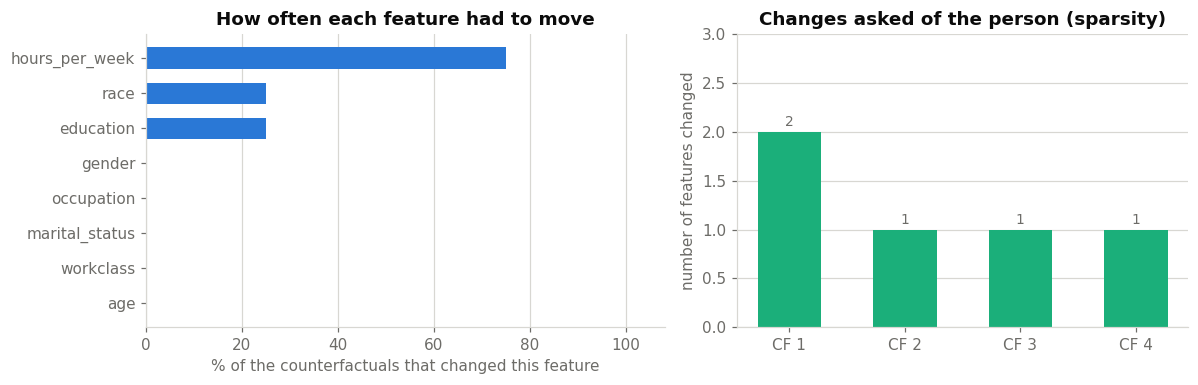

In [11]:
changed = pd.DataFrame(
    {f: (cf_df[f].values != orig[f]) for f in features},
    index=[f"CF {i + 1}" for i in range(len(cf_df))])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})

freq = changed.mean().sort_values() * 100
axes[0].barh(freq.index, freq.values, color=C["blue"], height=0.6)
axes[0].set_title("How often each feature had to move")
axes[0].set_xlabel("% of the counterfactuals that changed this feature")
axes[0].set_xlim(0, 108)
axes[0].xaxis.grid(True)
axes[0].set_axisbelow(True)

n_changed = changed.sum(axis=1)
axes[1].bar(n_changed.index, n_changed.values, color=C["aqua"], width=0.55)
axes[1].set_title("Changes asked of the person (sparsity)")
axes[1].set_ylabel("number of features changed")
axes[1].set_ylim(0, max(3, n_changed.max() + 1))
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)
for i, v in enumerate(n_changed.values):
    axes[1].text(i, v + 0.06, str(v), ha="center", color=C["muted"], fontsize=9)

plt.tight_layout()
plt.show()

And for the two numeric features, a **dumbbell chart** shows the size and direction
of the ask at a glance: grey is where the person is now, orange is where the
counterfactual wants them. A dot with no line means that feature did not move.

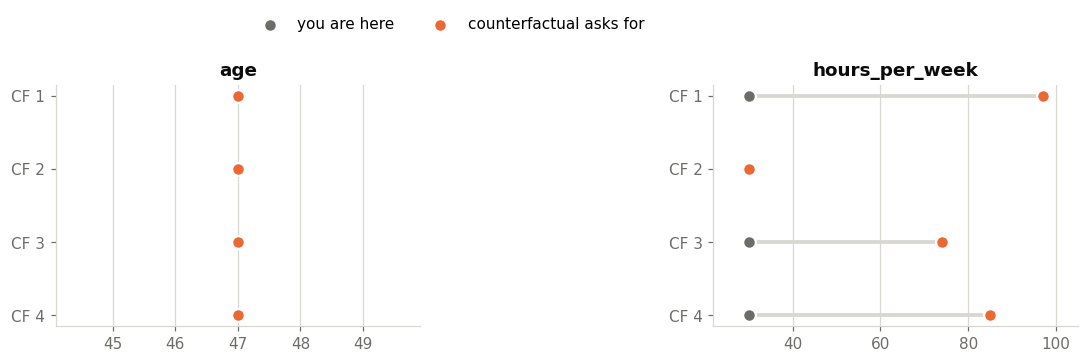

In [12]:
fig, axes = plt.subplots(1, len(continuous_features),
                         figsize=(10, 2.4 + 0.3 * len(cf_df)))

for ax, feat in zip(np.atleast_1d(axes), continuous_features):
    ys = np.arange(len(cf_df))
    ax.hlines(ys, orig[feat], cf_df[feat].values, color=C["grid"],
              linewidth=2.5, zorder=1)
    ax.scatter([orig[feat]] * len(cf_df), ys, s=70, color=C["muted"], zorder=2,
               edgecolor="white", linewidth=1.5, label="you are here")
    ax.scatter(cf_df[feat].values, ys, s=70, color=C["orange"], zorder=3,
               edgecolor="white", linewidth=1.5, label="counterfactual asks for")
    ax.set_yticks(ys, [f"CF {i + 1}" for i in ys])
    ax.invert_yaxis()
    ax.set_title(feat)
    ax.margins(x=0.12)
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)

np.atleast_1d(axes)[0].legend(loc="upper center", bbox_to_anchor=(1.08, 1.34),
                              ncol=2)
plt.tight_layout()
plt.show()

## 10. What makes a counterfactual *good*?

Flipping the prediction is the easy part. A counterfactual an actual person can use
has to clear five bars:

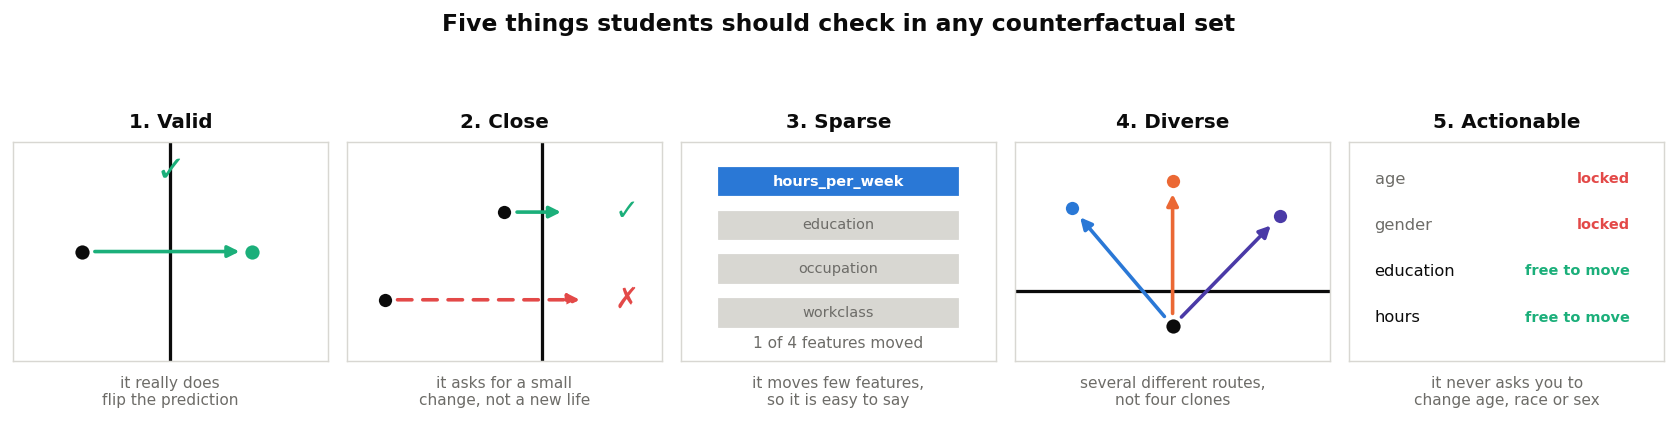

The first four are things DiCE optimises for. The fifth — **actionability** — is
domain knowledge that *you* have to supply. DiCE cannot know that age is not a
choice.

## 11. Making counterfactuals actionable

Two arguments do all the work:

* **`features_to_vary=[...]`** — a whitelist. Everything else is frozen.
* **`permitted_range={...}`** — legal values per feature: `[low, high]` for a
  continuous feature, a list of allowed categories for a categorical one.

Here we freeze the **immutable / protected** attributes (`age`, `race`, `gender`,
`marital_status`) and cap the working week at a humane 20–60 hours.

> **Discussion point for the class:** freezing `race` and `gender` makes the
> *explanation* non-discriminatory, but it does **not** make the *model* fair. If
> the model uses those features, they are still driving decisions — hiding them from
> the recourse only hides the evidence. Auditing and recourse are different jobs.

In [13]:
actionable = ["education", "occupation", "hours_per_week", "workclass"]

cf_actionable = exp_random.generate_counterfactuals(
    query_instance,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=actionable,
    permitted_range={"hours_per_week": [20, 60]},
)

cf_actionable.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.92it/s]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,47,Self-Employed,Bachelors,Married,Professional,White,Male,30,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,HS-grad,-,-,-,-,52,1
1,-,-,-,-,White-Collar,-,-,55,1
2,-,Private,Masters,-,-,-,-,-,1
3,-,-,Some-college,-,-,-,-,42,1


## 12. Measuring counterfactual quality

Four numbers, and every student should be able to compute them by hand:

| Metric | Definition | Direction |
|---|---|---|
| **Validity** | fraction of returned counterfactuals that really flip the prediction | higher is better (should be 1.0) |
| **Sparsity** | average number of features changed | **lower** is better |
| **Continuous proximity** | mean \|change\| divided by the feature's **MAD** (median absolute deviation) | **lower** is better |
| **Categorical proximity** | fraction of categorical features that changed | **lower** is better |

Dividing by the MAD is the important trick: it puts "5 more years of age" and
"12 more hours a week" on a comparable scale, and MAD is used instead of the standard
deviation because it is robust to the long income-data tails.

In [14]:
mads = {f: max(float(np.median(np.abs(x_train[f] - np.median(x_train[f])))), 1.0)
        for f in continuous_features}
print("MAD used for scaling:", mads)


def cf_quality(query_row, cf_frame):
    """validity / sparsity / proximity for one counterfactual set."""
    if len(cf_frame) == 0:
        return dict(n_cfs=0, validity=0.0, sparsity=np.nan,
                    cont_proximity=np.nan, cat_proximity=np.nan)

    cfs = cf_frame[features]
    target = 1 - int(model.predict(query_row[features].to_frame().T)[0])

    validity = float((model.predict(cfs) == target).mean())
    n_changed = sum((cfs[f].values != query_row[f]) for f in features)
    cont = np.mean([np.mean(np.abs(cfs[f].values - query_row[f]) / mads[f])
                    for f in continuous_features])
    cat = np.mean([np.mean(cfs[f].values != query_row[f])
                   for f in categorical_features])

    return dict(n_cfs=len(cfs), validity=validity,
                sparsity=float(np.mean(n_changed)),
                cont_proximity=float(cont), cat_proximity=float(cat))


pd.DataFrame([
    dict(setting="unconstrained", **cf_quality(orig, cf_df)),
    dict(setting="actionable only",
         **cf_quality(orig, cf_actionable.cf_examples_list[0].final_cfs_df)),
]).round(3)

MAD used for scaling: {'age': 10.0, 'hours_per_week': 4.0}


,setting,n_cfs,validity,sparsity,cont_proximity,cat_proximity
0,unconstrained,4,1.0,1.25,5.188,0.083
1,actionable only,4,1.0,2.00,1.844,0.208


Expect the constrained set to be **sparser and closer**. That is not luck: shrinking
the search space removes the cheap-but-useless escapes like *"be 20 years older"*,
so the search has to find recourse inside the levers the person actually controls.

## 13. Three search strategies, one question

Same person, same target — three different engines. Watch the trade-off between
**speed**, **sparsity** and **distance**.

`kdtree` deserves special attention: because it returns *actual training rows*, its
counterfactuals are guaranteed to be **realistic combinations** of features (no
16-year-old with a doctorate). The price is that it can only offer you profiles that
already exist in the data.

In [15]:
methods = ["random", "genetic", "kdtree"]
rows, cf_sets = [], {}

for meth in methods:
    exp = dice_ml.Dice(d, m, method=meth)
    t0 = time.time()
    res = exp.generate_counterfactuals(query_instance, total_CFs=4,
                                       desired_class="opposite")
    elapsed = time.time() - t0

    frame = res.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
    cf_sets[meth] = frame
    rows.append(dict(method=meth, seconds=round(elapsed, 2),
                     **cf_quality(orig, frame)))

comparison = pd.DataFrame(rows).round(3)
comparison

100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


,method,seconds,n_cfs,validity,sparsity,cont_proximity,cat_proximity
0,random,0.24,4,1.0,1.75,4.594,0.167
1,genetic,0.96,4,1.0,2.00,0.188,0.167
2,kdtree,0.68,4,1.0,2.50,0.112,0.250


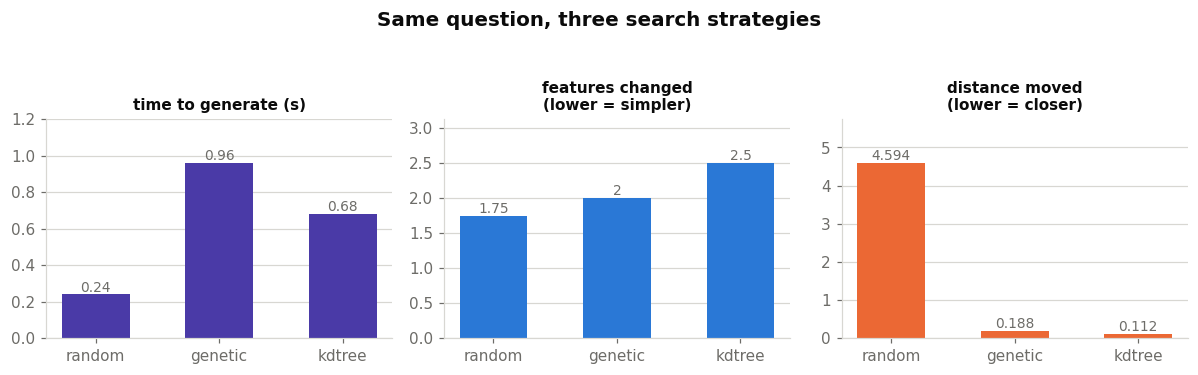

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

panels = [("seconds", "time to generate (s)", C["violet"]),
          ("sparsity", "features changed\n(lower = simpler)", C["blue"]),
          ("cont_proximity", "distance moved\n(lower = closer)", C["orange"])]

for ax, (col, title, colour) in zip(axes, panels):
    ax.bar(comparison["method"], comparison[col], color=colour, width=0.55)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, comparison[col].max() * 1.25 + 1e-6)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    for i, v in enumerate(comparison[col]):
        ax.text(i, v, f"{v:g}", ha="center", va="bottom", color=C["muted"],
                fontsize=9)

fig.suptitle("Same question, three search strategies", y=1.05, fontsize=13,
             fontweight="bold", color=C["ink"])
plt.tight_layout()
plt.show()

In [17]:
# Look at the kdtree counterfactuals - these are real people from the training set.
cf_sets["kdtree"]

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,46,Private,Bachelors,Married,Service,White,Male,30,1
1,44,Self-Employed,Bachelors,Married,Sales,White,Male,30,1
2,50,Self-Employed,Prof-school,Married,Professional,White,Male,30,1
3,45,Self-Employed,Prof-school,Single,Professional,White,Male,30,1


The proximity-heavy set should feel like *small, safe* advice; the diversity-heavy
set should feel like *several genuinely different life paths*, each further away.

**Which is right depends on who is reading it.** A bank sending one letter wants
proximity. A career counsellor exploring options with a client wants diversity.